<a href="dependencies/banner.jpeg">
      <img src="dependencies/banner.jpeg" alt="image0" width="100%">
</a>

# Two-qubit randomized benchmarking
Two-qubit randomized benchmarking characterizes the overall Clifford (in)fidelity, which includes contributions
from both single- and two-qubit gates.
For this experiment a random sequence of two-qubit Cliffords is generated (one sequence per seed),
and for each experiment an increasing portion of this sequence is executed (different gate
string lengths $m$) before the two qubits are returned to their initial states. A fit of the exponential
decay of the overlap between initial and final states gives the average error per gate,
while the variance in this $⟨\psi_f|\psi_i⟩$ overlap between seeds for the same gate string
length gives an estimate of the degree to which this error is coherent.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dependencies.randomized_benchmarking.clifford_group import TwoQubitCliffordCZ
from dependencies.randomized_benchmarking.utils import randomized_benchmarking_schedule

from qblox_scheduler import HardwareAgent

Generating hash table for SingleQubitClifford.
Hash table generated.
Generating hash table for TwoQubitCliffordCZ.


Hash table generated.
Generating hash table for TwoQubitCliffordZX.


Hash table generated.


/.venv/lib/python3.14/site-packages/quantify_core/visualization/instrument_monitor.py:13: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import strip_attrs


## Setup
The hardware agent manages the connection to the instrument and ensures that pulses and acquisitions happen over the appropriate input and output channels of the Cluster.
The cell below creates an instance of the `HardwareAgent` based on the hardware- and device-under-test configuration files in the `./dependencies/configs` folder, allowing us to start doing measurements.
We also define some convenient aliases to use throughout our measurements.
For a more thorough discussion of the hardware- and device-under-test configuration files, check out [this tutorial](000_transmon_setup.ipynb).

In [2]:
# Set up hardware agent, this automatically connects to the instrument
hw_agent = HardwareAgent(
    hardware_configuration="./dependencies/configs/hw_config.json",
    quantum_device_configuration="./dependencies/configs/dut_config.json",
)

# convenience aliases
q0 = hw_agent.quantum_device.get_element("q0")  # Qubits 0 and 2 are measured using QRM-RF + QCM-RF
q2 = hw_agent.quantum_device.get_element("q2")
q3 = hw_agent.quantum_device.get_element("q3")  # Qubit 3 is measured using QRC

cluster = hw_agent.get_clusters()["cluster"]
hw_options = hw_agent.hardware_configuration.hardware_options
qubit = q0

/.venv/lib/python3.14/site-packages/qblox_scheduler/qblox/hardware_agent.py:556: UserWarning: cluster: Trying to instantiate cluster with ip 'None'.Creating a dummy cluster.
  warnings.warn(


## Experiment settings

In [3]:
# RB settings
lengths = [1]  # number
seeds = np.random.randint(0, 2**31 - 1, size=1, dtype=np.int32)  # number
repetitions = 1

## Experiment schedule

In [4]:
sched = randomized_benchmarking_schedule(
    [q0.name, q2.name],
    lengths=lengths,
    repetitions=repetitions,
    seeds=seeds,
    generator=TwoQubitCliffordCZ,  # Change to the appropriate gate for your architecture!
)

# Compile the schedule
comp_sched = hw_agent.compile(sched)

## Show the schedule

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


...

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


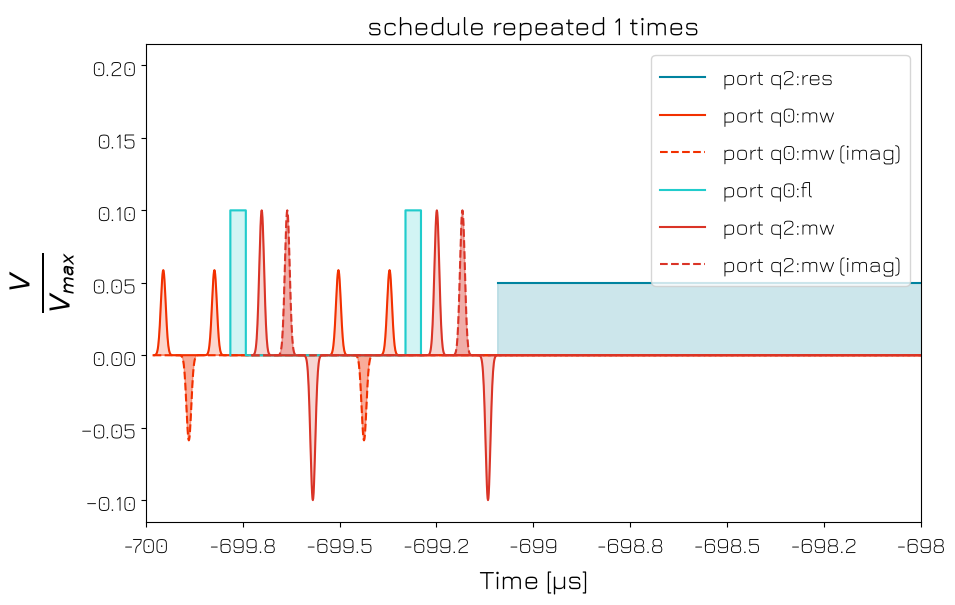

In [5]:
fig, ax = comp_sched.plot_pulse_diagram(plot_backend="mpl")
ax.set_xlim(q2.reset.duration, q2.reset.duration + 2e-6)
plt.show()